# 🧽 Stage 2 · Cleaning

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DreamEmulator/rtu-computer-vision/blob/main/02_image-preprocessing/cleaning.ipynb)

**Topic of the week:** Image Preprocessing Methods · **Lecture:** Thu 24.09 · **Startup question:** *Our clip-on camera is cheap. Can we trust its pixels?*

Cheap sensors add noise, and some pixels are simply dead (always black) or hot (always white). A filter replaces every pixel with a combination of its neighbours. The art is removing the noise without removing the drop.

| In the CI-pipeline | |
|---|---|
| Why? | [`README.md`](README.md) |
| How? — the 🎛️ tinker zone | [`cleaning_denoise/action.yaml`](cleaning_denoise/action.yaml) |
| What? — Step 0 to 3 | [`Todo_Cleaning.md`](Todo_Cleaning.md) |
| Code | `stages/s2_cleaning.py` |

This notebook imports the **same functions** CI runs, with the values from your tinker zone. Explore here, then commit your choice to the tinker zone on a branch and let CI prove it.

In [1]:
# ⚙️ Setup — works locally, in Codespaces and in Colab (Colab already has every library we need)
import os, subprocess, sys
REPO = "DreamEmulator/rtu-computer-vision"  # filled in automatically in your own copy of the template
here = os.getcwd()
while not os.path.exists("run_pipeline.py") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")                      # notebooks live in the topic folders; the pipeline root is up
if not os.path.exists("run_pipeline.py"):   # Colab: fetch the repository first
    os.chdir(here)
    if not os.path.exists("repo"):
        subprocess.run(["git", "clone", "-q", f"https://github.com/{REPO}.git", "repo"], check=True)
    os.chdir("repo")
sys.path.insert(0, os.getcwd())

import cv2, json, numpy as np, matplotlib.pyplot as plt
from stages.common import load_images, to_luma
from stages.nb import prepare, run_stage, show
%matplotlib inline

In [2]:
cfg = prepare("digital_data")
from stages.s2_cleaning import clean, estimate_noise, sharpness
s1 = load_images("digital_data")
noise = np.array([estimate_noise(im) for im in s1.images])
worst = int(noise.argmax())
img = s1.images[worst]
print(f"Noisiest frame: {s1.rows[worst]['file']}  σ ≈ {noise[worst]:.1f}   (median over all frames: {np.median(noise):.1f})")

✔ Stages up to 'digital_data' ran with your tinker-zone values
Noisiest frame: 00233_low_fluid.png  σ ≈ 11.4   (median over all frames: 4.8)


## Gaussian vs median, zoomed in
σ is the estimated noise left (Immerkær's method, the same number the quality gate checks).

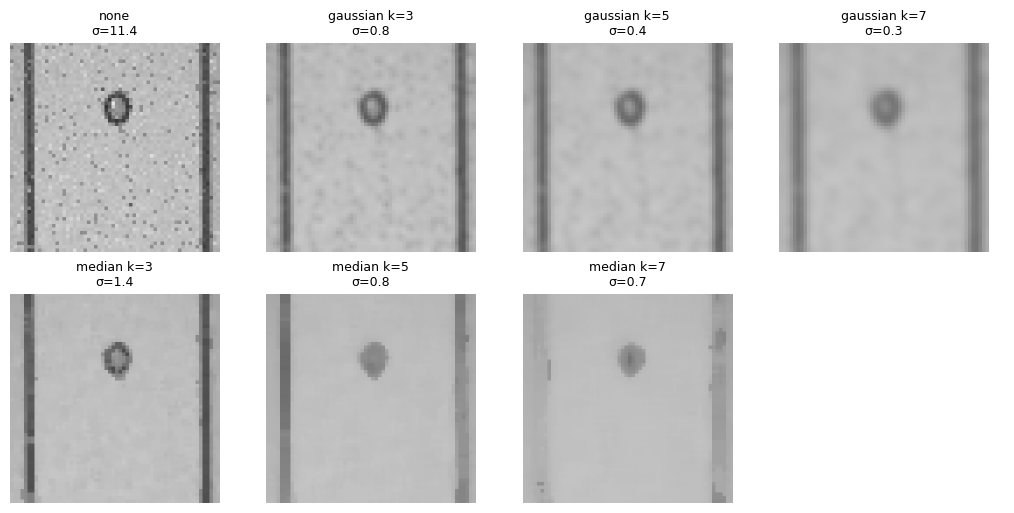

In [3]:
zoom = lambda im: cv2.resize(im[34:94, 34:94], (180, 180), interpolation=cv2.INTER_NEAREST)
tries = [("none", {"method": "none"})] + [(f"{m} k={k}", {"method": m, "kernel": k})
                                          for m in ("gaussian", "median") for k in (3, 5, 7)]
outs = [clean(img, c) for _, c in tries]
show([zoom(o) for o in outs], [f"{n}\nσ={estimate_noise(o):.1f}" for (n, _), o in zip(tries, outs)],
     cols=4, color_space=s1.color_space)

## The trade-off
Bigger kernels remove more noise, and more detail. The drop is only a few pixels wide at 128×128, so detail matters.

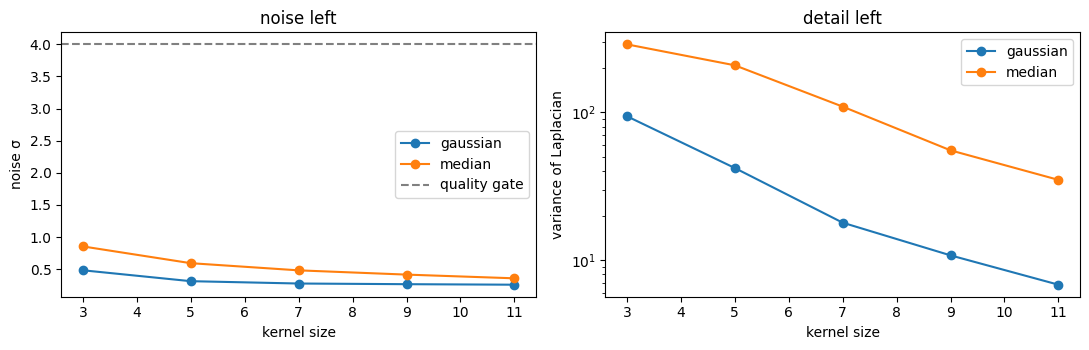

In [4]:
sample, ks = s1.images[::6], [3, 5, 7, 9, 11]
fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.6))
for m in ("gaussian", "median"):
    cleaned = [[clean(im, {"method": m, "kernel": k}) for im in sample] for k in ks]
    a.plot(ks, [np.mean([estimate_noise(c) for c in cs]) for cs in cleaned], "o-", label=m)
    b.plot(ks, [np.mean([sharpness(c) for c in cs]) for cs in cleaned], "o-", label=m)
if cfg["cleaning"].get("gate_max_noise") is not None:
    a.axhline(cfg["cleaning"]["gate_max_noise"], ls="--", c="gray", label="quality gate")
a.set(xlabel="kernel size", ylabel="noise σ", title="noise left")
b.set(xlabel="kernel size", ylabel="variance of Laplacian", title="detail left", yscale="log")
a.legend(); b.legend(); plt.tight_layout(); plt.show()

## Play with it

In [5]:
try:
    from ipywidgets import interact
    @interact(method=["gaussian", "median", "bilateral"], kernel=(3, 15, 2))
    def _(method="median", kernel=3):
        out = clean(img, {"method": method, "kernel": kernel})
        show([zoom(img), zoom(out)], ["input", f"{method} k={kernel}  σ={estimate_noise(out):.1f}"], size=4)
except ImportError:
    print("pip install ipywidgets for a slider version")

pip install ipywidgets for a slider version


## 🧪 Your turn
1. Why does the median filter delete dead pixels while the Gaussian only smears them? (Think about what an average and a median do with one extreme value.)
2. Find the smallest kernel that passes the noise gate for each method. Which one keeps more detail?
3. Set `method: none` in the tinker zone. Which stage breaks, and does stage 6 even get to run?

## 🚀 Ship your choice

1. Create a branch: `experiment/<what-you-change>`
2. Change **one** value in the 🎛️ TINKER ZONE of this topic's `action.yaml`
3. Push and open a pull request. The PR template asks for your hypothesis and result.
4. Compare the 🎤 Demo Day table of your PR with the one on `main`. Better? Merge. Not better? Close it and write down why — that's R&D too.